In [79]:
import sys
from pathlib import Path

# add parent folder to python path
sys.path.append(str(Path.cwd().parent))

In [80]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [81]:
import os
import json
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np
from utils import   show_images
from tqdm import tqdm
from data_handlers.datasets import UDAFrameDataset
from utils.file_management import serialize_config,get_version_folder
from utils.augmentation import Augmentations
from model import EncoderDecoder
import torchvision.utils as vutils


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# binary_mask = torch.load('cache/utils/binary_mask.pt').to(device)

In [82]:
root = 'cache/model_weights/supplementary_vector'
index_folder = get_version_folder(root)

In [ ]:
config= {
    'lr': 1e-4,
    'epochs': 10,
    'batch_size' : 32,
    'transformations' :None,
    'model_path':os.path.join(index_folder,'model.pt'),
    'samples_path':os.path.join(index_folder,'samples'),
    'bottleneck_dim':128,
    'number_of_frames':1,
    'number_of_vectors':4σ,
    'vectorizers_mat_mul':[True,True,True,True,False],#[True,True,True,True,False],
    'add_checkboard':False
}

config_json= serialize_config(config)
with open(os.path.join(index_folder,'config.json'),'w') as f:
    json.dump(config_json,f,indent=2)
os.mkdir(config['samples_path'])

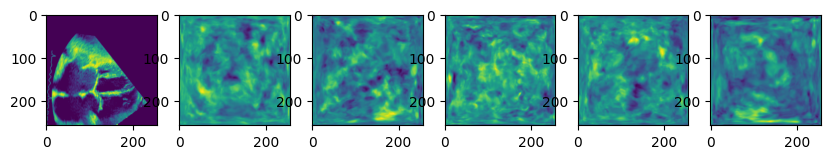

In [84]:
model = EncoderDecoder(bottleneck_dim=config['bottleneck_dim'],
                        number_of_vectors = config['number_of_vectors'],
                        vectorizers_mat_mul=  config['vectorizers_mat_mul'],
                        save_path = config['model_path']).to(device)

                 
optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'])

dataset = UDAFrameDataset(number_of_frames=config['number_of_frames'])
train_loader = torch.utils.data.DataLoader(dataset, batch_size=config['batch_size'], shuffle=True)

losses =[]

augmentations = Augmentations( degrees=30,
                                translate=(0.0, 0.3),
                                scale=(0.9, 1.1),
                                shear=15,
                                add_checkboard=config['add_checkboard'])
data = next(iter(train_loader))
data = augmentations(data)
data = data.to(device)[:,0]
with torch.no_grad():
    rec,seg= model(data)


components = rec.shape[1]
fig,ax = plt.subplots(1,components+1,figsize=(10,5))
ax[0].imshow(data.cpu().numpy()[0,0])
for i in range(components):
    ax[i+1].imshow(seg.cpu().numpy()[0,i])



In [85]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TotalVariationLoss(nn.Module):
    def __init__(self, weight=5.0):
        super().__init__()
        self.weight = weight

    def forward(self, probs):
        # probs shape: (B, C, H, W)
        diff_y = torch.abs(probs[:, :, 1:, :] - probs[:, :, :-1, :])
        diff_x = torch.abs(probs[:, :, :, 1:] - probs[:, :, :, :-1])
        return self.weight * (diff_y.mean() + diff_x.mean())

class SpatialCompactnessLoss(nn.Module):
    def __init__(self, weight=10.0):
        super().__init__()
        self.weight = weight
        self.x_grid = None
        self.y_grid = None

    def forward(self, probs):
        B, C, H, W = probs.shape
        device = probs.device
        
        # Dynamically create and cache the coordinate grid to save compute
        if self.x_grid is None or self.x_grid.shape != (1, 1, H, W):
            y_grid, x_grid = torch.meshgrid(torch.arange(H, device=device), 
                                            torch.arange(W, device=device), indexing='ij')
            self.y_grid = (y_grid.float() / H).unsqueeze(0).unsqueeze(0) # Shape: (1, 1, H, W)
            self.x_grid = (x_grid.float() / W).unsqueeze(0).unsqueeze(0)

        compactness_loss = 0.0
        for k in range(C):
            # Isolate channel k
            prob_k = probs[:, k:k+1, :, :] # Shape: (B, 1, H, W)
            prob_sum = prob_k.sum(dim=(2,3), keepdim=True) + 1e-6 
            
            # Center of mass (cx, cy)
            cx = (prob_k * self.x_grid).sum(dim=(2,3), keepdim=True) / prob_sum
            cy = (prob_k * self.y_grid).sum(dim=(2,3), keepdim=True) / prob_sum
            
            # Spatial variance (spread around the center of mass)
            var_x = (prob_k * (self.x_grid - cx)**2).sum(dim=(2,3)) / prob_sum.squeeze(-1).squeeze(-1)
            var_y = (prob_k * (self.y_grid - cy)**2).sum(dim=(2,3)) / prob_sum.squeeze(-1).squeeze(-1)
            
            compactness_loss += (var_x + var_y).mean()
            
        return self.weight * compactness_loss
    
criterion_tv = TotalVariationLoss(weight=50.0)
criterion_compactness = SpatialCompactnessLoss(weight=10.0)

In [86]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class AnatomicalCenteredPositionLoss(nn.Module):
    def __init__(self, target_dx=0.2, target_dy=0.2, rel_weight=5.0, gravity_weight=5.0):
        super().__init__()
        self.target_dx = target_dx
        self.target_dy = target_dy
        self.rel_weight = rel_weight
        self.gravity_weight = gravity_weight
        
        self.x_grid = None
        self.y_grid = None

    def forward(self, probs, frame):
        """
        probs: Tensor of shape (B, 4, H, W) - The 4 foreground masks
        frame: Tensor of shape (B, 1, H, W) - The original ultrasound image
        """
        B, C, H, W = probs.shape
        device = probs.device
        
        # Cache grids (normalized 0 to 1)
        if self.x_grid is None or self.x_grid.shape != (1, 1, H, W):
            y_grid, x_grid = torch.meshgrid(torch.arange(H, device=device), 
                                            torch.arange(W, device=device), indexing='ij')
            self.y_grid = (y_grid.float() / H).unsqueeze(0).unsqueeze(0)
            self.x_grid = (x_grid.float() / W).unsqueeze(0).unsqueeze(0)

        # ---------------------------------------------------------
        # 1. FIND THE ANATOMICAL CENTER (From the image)
        # ---------------------------------------------------------
        # We use the raw frame intensities to find the center of the tissue
        # Adding epsilon to prevent division by zero if an image is completely black
        img_sum = frame.sum(dim=(2,3)) + 1e-6 
        
        # Calculate tissue center of mass (Shape: [B, 1])
        tissue_cx = (frame * self.x_grid).sum(dim=(2,3)) / img_sum
        tissue_cy = (frame * self.y_grid).sum(dim=(2,3)) / img_sum

        # ---------------------------------------------------------
        # 2. CALCULATE MASK CENTERS OF MASS
        # ---------------------------------------------------------
        cx = torch.zeros((B, C), device=device)
        cy = torch.zeros((B, C), device=device)
        
        for k in range(C):
            prob_k = probs[:, k:k+1, :, :]
            prob_sum = prob_k.sum(dim=(2,3)) + 1e-6 
            cx[:, k] = (prob_k * self.x_grid).sum(dim=(2,3)).squeeze(-1) / prob_sum.squeeze(-1)
            cy[:, k] = (prob_k * self.y_grid).sum(dim=(2,3)).squeeze(-1) / prob_sum.squeeze(-1)

        # ---------------------------------------------------------
        # 3. RELATIVE POSITION (The "Push" into quadrants)
        # ---------------------------------------------------------
        # 0=Top-Left, 1=Top-Right, 2=Bottom-Left, 3=Bottom-Right
        dx_ventricles = cx[:, 1] - cx[:, 0] 
        dx_atria = cx[:, 3] - cx[:, 2]      
        dy_right = cy[:, 2] - cy[:, 0]      
        dy_left = cy[:, 3] - cy[:, 1]       

        loss_x = F.relu(self.target_dx - dx_ventricles).mean() + F.relu(self.target_dx - dx_atria).mean()
        loss_y = F.relu(self.target_dy - dy_right).mean() + F.relu(self.target_dy - dy_left).mean()
        
        relative_loss = self.rel_weight * (loss_x + loss_y)

        # ---------------------------------------------------------
        # 4. DYNAMIC CENTER GRAVITY (The "Pull" to the tissue)
        # ---------------------------------------------------------
        # We expand the tissue center to match the shape of the mask centers [B, C]
        target_cx = tissue_cx.expand(-1, C)
        target_cy = tissue_cy.expand(-1, C)
        
        # Pull the masks towards the actual bright tissue in the ultrasound
        gravity_loss = self.gravity_weight * (F.mse_loss(cx, target_cx) + F.mse_loss(cy, target_cy))

        return relative_loss + gravity_loss


In [87]:
criterion_position = AnatomicalCenteredPositionLoss(target_dx=0.2, target_dy=0.2, rel_weight=5.0, gravity_weight=10.0)

In [104]:
epochs  =10
for epoch in range(epochs):
    loop = tqdm(train_loader,desc=f'Epoch {epoch}/{epochs}')
    for data in loop:
        data = augmentations(data)
        optimizer.zero_grad()
        frame = data[:,0].to(device)    
        rec,seg= model(frame)
        num_classes = seg.shape[1]
       

        with torch.no_grad():
            pixelwise_error = (rec - frame)**2 
            target_mask = torch.argmin(pixelwise_error, dim=1) 


        seg_loss = F.cross_entropy(seg, target_mask)

        seg_probs = F.softmax(seg, dim=1)
        
        bg_area_loss =  1*  seg_probs[:, -1].mean()
        hard_masks = F.one_hot(torch.argmax(seg_probs.detach(), dim=1), num_classes=num_classes)
        hard_masks = hard_masks.permute(0, 3, 1, 2).float() # Shape: (B, 5, H, W)

        # Apply the detached binary masks to the reconstructions
        reconstruction = torch.sum(hard_masks * rec, dim=1).unsqueeze(1) # Shape: (B, 1, H, W)

        # Standard reconstruction loss
        recon_loss = 100* F.mse_loss(reconstruction, frame)

        partial_recon_loss  = 0 
        for i in range(num_classes):
            with torch.no_grad():
                partial_weight_denominator = seg_probs[:,i].mean()
                partial_weight_denominator = partial_weight_denominator.detach()
                partial_weight_denominator = partial_weight_denominator.item()
            partial_recon_loss += 1* F.mse_loss(rec[:,i].unsqueeze(1), frame) / partial_weight_denominator

        fg_probs = seg_probs[:, :-1, :, :] 
          # NEW: Apply relative position loss to the 4 foreground heads
        pos_loss = criterion_position(fg_probs,frame)
        tv_loss = criterion_tv(fg_probs)
        compact_loss = criterion_compactness(fg_probs)

        loss = seg_loss + recon_loss + bg_area_loss + partial_recon_loss + tv_loss + compact_loss+pos_loss
        loop.set_postfix(recon_loss=recon_loss.item(),
                         seg_loss = seg_loss.item(),
                         bg_area_loss=bg_area_loss.item(),
                         partial_recon_loss=partial_recon_loss.item(),
                         tv_loss = tv_loss.item(),
                         compact_loss = compact_loss.item(),
                         pos_loss= pos_loss.item()
                         )
        loss.backward()
        optimizer.step()
        losses.append(loss.item()) 


Epoch 9/10: 100%|██████████| 1179/1179 [14:22<00:00,  1.37it/s, bg_area_loss=0.89, compact_loss=0.394, partial_recon_loss=2.93, pos_loss=0.236, recon_loss=0.898, seg_loss=1.01, tv_loss=0.134]  


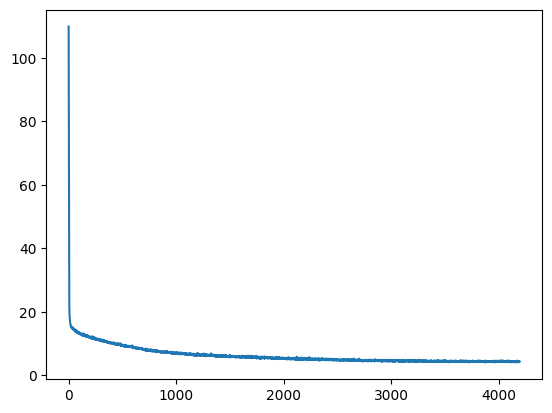

In [ ]:
plt.plot(losses)

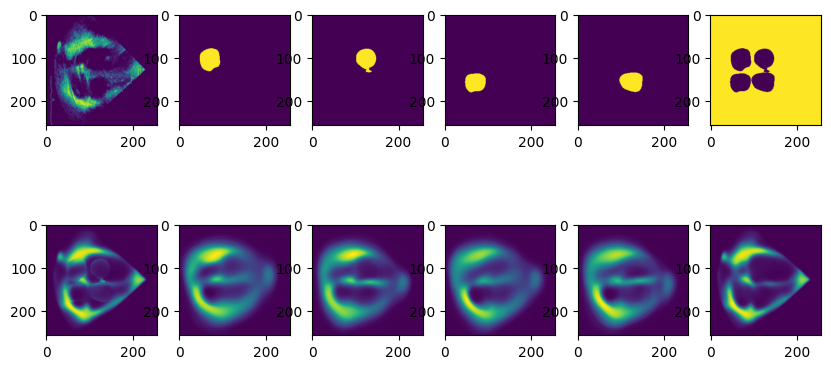

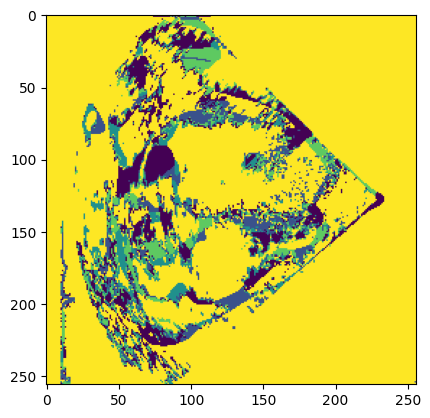

In [ ]:
data = next(iter(train_loader))
data = augmentations(data,train=False)[:,0].to(device)
data = data.to(device)
with torch.no_grad():
    rec,seg= model(data)
    seg_probs = F.softmax(seg, dim=1)
    hard_masks = F.one_hot(torch.argmax(seg_probs.detach(), dim=1), num_classes=num_classes)
    hard_masks = hard_masks.permute(0, 3, 1, 2).float() # Shape: (B, 5, H, W)

    pixelwise_error = (rec - data)**2 
    target_mask = torch.argmin(pixelwise_error, dim=1) 

    # Apply the detached binary masks to the reconstructions
    reconstruction = torch.sum(hard_masks * rec, dim=1).unsqueeze(1) # Shape: (B, 1, H, W)

components = rec.shape[1]
fig,ax = plt.subplots(2,components+1,figsize=(10,5))
ax[0,0].imshow(data.cpu().numpy()[0,0])
for i in range(components):
    ax[0,i+1].imshow(hard_masks.cpu().numpy()[0,i])


ax[1,0].imshow(reconstruction.cpu().numpy()[0,0])
for i in range(components):
    ax[1,i+1].imshow(rec.cpu().numpy()[0,i])
plt.show()
plt.imshow(target_mask.cpu()[0])
